# Smart Price — Previsão de Valor de Aluguel Residencial

## Contexto

A **Smart Price** é uma plataforma de gestão imobiliária que quer parar de precificar aluguel no olho. Hoje o proprietário chuta o valor olhando o vizinho; se erra pra cima o imóvel fica encalhado, se erra pra baixo perde receita todo mês do contrato.

O pedido é um modelo que estime o aluguel a partir das características do imóvel e da localização, e uma plataforma em Streamlit onde corretor e proprietário simulem o valor e naveguem pelas tendências de cada bairro.

A base é um raspão de anúncios do ZAP Imóveis coletado até julho de 2020: 35.772 anúncios, 78 colunas, 331 cidades.

## Estrutura do notebook

1. Setup e carregamento
2. Qualidade dos dados (sentinela, separador decimal, duplicatas)
3. Definição do alvo — aluguel puro ou custo total
4. Outliers
5. Limpeza dos nulos (imputação explorada, coluna a coluna)
6. EDA — o que move o preço
7. Recorte geográfico da base modelável
8. Feature engineering
9. Modelagem — comparação entre modelos
10. Diagnóstico do modelo
11. Exportação dos artefatos pro Streamlit
12. Resumo

## 1. Setup e carregamento

In [1]:
# !pip install lightgbm xgboost shap -q
import pandas as pd, numpy as np, warnings, joblib, json, re
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']=110; sns.set_style('whitegrid')
AZUL='steelblue'; VERM='#d9534f'; VERD='#2e8b57'; LARANJA='#e08a3c'

raw = pd.read_csv('dataZAP.csv', sep=';', low_memory=False, dtype=str)
print(f'base bruta: {raw.shape[0]:,} anuncios x {raw.shape[1]} colunas')
print('periodo:', raw['listing.createdAt'].str[:7].min(), 'a', raw['listing.createdAt'].str[:7].max())

base bruta: 35,772 anuncios x 78 colunas
periodo: 2005-12 a 2020-07


li tudo como texto de proposito. essa base tem duas armadilhas de leitura que se eu deixar o pandas adivinhar o tipo eu levo pro resto do case sem perceber.

## 2. Qualidade dos dados

In [2]:
# armadilha 1: o dataset usa a string 'normal' como codigo de nulo
tem_normal = (raw=='normal').sum()
tem_normal = tem_normal[tem_normal>0].sort_values(ascending=False)
print("colunas com a sentinela 'normal' (top 12):")
print((tem_normal/len(raw)*100).round(1).head(12).to_string())

colunas com a sentinela 'normal' (top 12):
listing.floors                          92.9
listing.legacyId                        89.7
listing.unitSubTypes                    89.0
type                                    80.7
listing.pricingInfo.salePrice           73.3
listing.address.streetNumber            47.7
listing.pricingInfo.yearlyIptu          31.7
listing.pricingInfo.rentalTotalPrice    31.0
listing.pricingInfo.monthlyCondoFee     30.8
listing.address.street                  24.8
listing.amenities                       24.1
listing.suites                          20.2


`normal` não é categoria, é o "não informado" do dataset. em `floors` é 92% da coluna, em `rentalTotalPrice`, `monthlyCondoFee` e `yearlyIptu` bate 31%.

se eu deixar passar, o pandas trata a coluna inteira como texto e ela morre no modelo. troco por NaN antes de qualquer coisa.

In [3]:
df = raw.replace('normal', np.nan)

# armadilha 2: o preco vem com ponto como separador de MILHAR ('1.300' = mil e trezentos)
print('amostra crua de rentalPrice:', raw['listing.pricingInfo.rentalPrice'].head(4).tolist())
print('lendo direto no pandas    :', pd.to_numeric(raw['listing.pricingInfo.rentalPrice'].head(4), errors='coerce').tolist())

amostra crua de rentalPrice: ['1.300', '3.600', '2.100', '3.000']
lendo direto no pandas    : [1.3, 3.6, 2.1, 3.0]


o `1.300` viraria `1.3`. o gráfico continua saindo bonito e o case inteiro fica errado. tiro o ponto antes de converter.

In [4]:
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace('.','',regex=False), errors='coerce')

num_cols = ['listing.pricingInfo.rentalPrice','listing.pricingInfo.rentalTotalPrice',
            'listing.pricingInfo.monthlyCondoFee','listing.pricingInfo.yearlyIptu',
            'listing.usableAreas','listing.totalAreas','listing.bathrooms','listing.bedrooms',
            'listing.suites','listing.parkingSpaces']
for c in num_cols: df[c] = to_num(df[c])
df['lat'] = pd.to_numeric(df['listing.address.point.lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['listing.address.point.lon'], errors='coerce')

print('aluguel  -> mediana R$', f"{df['listing.pricingInfo.rentalPrice'].median():,.0f}",
      '| min R$', f"{df['listing.pricingInfo.rentalPrice'].min():,.0f}",
      '| max R$', f"{df['listing.pricingInfo.rentalPrice'].max():,.0f}")
print('area util-> mediana', df['listing.usableAreas'].median(), 'm2 | max', f"{df['listing.usableAreas'].max():,.0f}", 'm2')

aluguel  -> mediana R$ 2,300 | min R$ 80 | max R$ 950,000
area util-> mediana 80.0 m2 | max 9,999,999 m2


agora sim. mediana de R$ 2.300 de aluguel é um número de mercado. e já aparece o problema seguinte: 950 mil de aluguel e área de 10 milhões de m² não existem, isso é lixo de digitação que eu trato na seção 4.

antes disso, duplicata.

In [5]:
print('linhas 100% identicas :', f'{df.duplicated().sum():,}')
print('listing.id repetido   :', f"{df['listing.id'].duplicated().sum():,}",
      f"({df['listing.id'].duplicated().mean()*100:.0f}% da base)")

ex = df[df['listing.id'].duplicated(keep=False)].sort_values('listing.id')
cols_ex = ['listing.id','listing.address.city','listing.pricingInfo.rentalPrice','listing.usableAreas','listing.createdAt','listing.updatedAt']
print()
print(ex[cols_ex].head(4).to_string(index=False))

linhas 100% identicas : 10,341
listing.id repetido   : 10,418 (29% da base)



listing.id listing.address.city  listing.pricingInfo.rentalPrice  listing.usableAreas        listing.createdAt        listing.updatedAt
1037521589     Lauro de Freitas                             3700                240.0 2018-06-05T19:46:20.115Z 2020-07-29T21:28:16.531Z
1037521589     Lauro de Freitas                             3700                240.0 2018-06-05T19:46:20.115Z 2020-07-29T21:28:16.531Z
1037521589     Lauro de Freitas                             3700                240.0 2018-06-05T19:46:20.115Z 2020-07-29T21:28:16.531Z
1038194194              Peruíbe                             2500                200.0 2018-06-27T14:18:49.604Z 2020-06-02T22:05:02.295Z


29% da base é o mesmo anúncio republicado (mesmo `listing.id`, mesmo preço, mesma área, só muda a data de atualização). isso não é imóvel a mais, é o mesmo imóvel contado várias vezes.

duplicata aqui é grave por dois motivos: infla o peso dos bairros onde a imobiliária republica mais, e faz o mesmo anúncio cair no treino e no teste, o que infla a métrica do modelo sem ele ter aprendido nada.

In [6]:
df = df.drop_duplicates(subset='listing.id')
chave = ['listing.address.city','listing.address.neighborhood','listing.pricingInfo.rentalPrice',
         'listing.usableAreas','listing.bedrooms','listing.bathrooms','account.name']
antes = len(df)
df = df.drop_duplicates(subset=chave)
print(f'apos remover id repetido e anuncio identico de mesma imobiliaria: {len(df):,} anuncios')
print(f'  ({antes-len(df):,} eram o mesmo imovel anunciado com id diferente)')

apos remover id repetido e anuncio identico de mesma imobiliaria: 24,263 anuncios
  (1,091 eram o mesmo imovel anunciado com id diferente)


de 35,8 mil anúncios sobraram 24,3 mil. 10,4 mil eram `listing.id` repetido e outros 1,1 mil eram o mesmo imóvel republicado com id novo pela mesma imobiliária. 32% da base era repetição.

## 3. Definição do alvo

A base traz dois candidatos a alvo e a escolha muda o produto inteiro:

| coluna | o que é | nulos |
|---|---|---|
| `rentalPrice` | aluguel puro, o que vai pro proprietário | 0% |
| `rentalTotalPrice` | o que o inquilino paga no total | 31% |

Antes de escolher no gosto, olho como as duas se relacionam.

In [7]:
p   = df['listing.pricingInfo.rentalPrice']
tot = df['listing.pricingInfo.rentalTotalPrice']
con = df['listing.pricingInfo.monthlyCondoFee']
ipt = df['listing.pricingInfo.yearlyIptu']

m = tot.notna() & con.notna()
print('anuncios com total e condominio preenchidos:', f'{m.sum():,}')
print('total == aluguel + condominio        :', f'{((tot-(p+con)).abs()<1)[m].mean()*100:.1f}% dos casos')
print('total == aluguel + condominio + iptu :', f'{((tot-(p+con+ipt)).abs()<1)[m & ipt.notna()].mean()*100:.1f}% dos casos')
print()
print(pd.DataFrame({'total':tot,'aluguel':p,'condominio':con,'iptu':ipt})[m].head(5).to_string(index=False))
print()
print('total nulo x condominio nulo:')
print(pd.crosstab(tot.isna().rename('total nulo'), con.isna().rename('condominio nulo')).to_string())

anuncios com total e condominio preenchidos: 17,123
total == aluguel + condominio        : 100.0% dos casos
total == aluguel + condominio + iptu : 0.0% dos casos

   total  aluguel  condominio  iptu
  1350.0     1300        50.0  50.0
  5561.0     3600      1961.0 370.0
  2935.0     2100       835.0 244.0
137437.0     3000    134437.0  90.0
  3136.0     2600       536.0  17.0

total nulo x condominio nulo:
condominio nulo  False  True 
total nulo                   
False            17123      0
True                47   7093


achei. o `rentalTotalPrice` **não é uma variável nova**, é `aluguel + condomínio`, conta fechada em 100% das linhas. e ele só é nulo quando o condomínio é nulo (47 exceções em 24 mil linhas) — ou seja, os 31% de nulo dele não são "preço faltando", são "condomínio faltando".

por isso o alvo é o **`rentalPrice`**:

- é o preço que o cliente da Smart Price realmente decide. condomínio quem define é a assembleia do prédio, o proprietário não mexe nisso.
- não tem nulo nenhum. se eu fosse de total, teria que imputar 31% do próprio alvo, e treinar em cima de alvo inventado é o pior tipo de vazamento — o modelo aprende a minha regra de imputação, não o mercado.
- e eu não perco o custo total: como a identidade é exata, o app mostra `aluguel previsto + condomínio` e entrega os dois números. modelo mais limpo, produto mais completo.

In [8]:
df = df[df['listing.usageTypes'].str.contains('RESIDENTIAL', na=False)]
print('anuncios residenciais:', f'{len(df):,}')
print('tipo de negocio:', df['listing.pricingInfo.businessType'].value_counts().to_dict())

anuncios residenciais: 24,263
tipo de negocio: {'RENTAL': 17856, 'RENTAL_SALE': 6043, 'SALE_RENTAL': 364}


todo mundo que sobrou tem aluguel. o `RENTAL_SALE` é imóvel anunciado pra alugar **e** vender ao mesmo tempo, o preço de aluguel dele é válido, então fica.

## 4. Outliers

Três colunas com cauda absurda: aluguel, área útil e o R$/m² que sai da divisão das duas. Vou olhar antes de cortar, porque cauda longa em imóvel é normal (cobertura em Ibirapuera é cara mesmo) e o que eu quero tirar é erro de digitação, não imóvel de luxo.

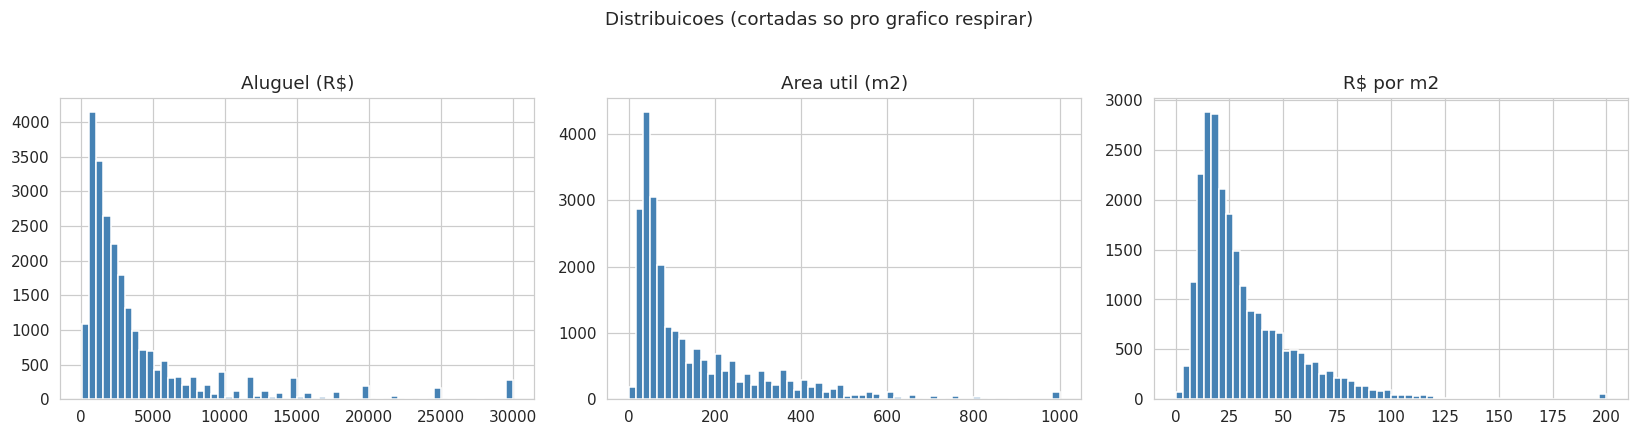

percentis extremos:
       aluguel    area   R$/m2
0.001    250.0    10.0     1.4
0.010    420.0    18.0     5.7
0.500   2250.0    80.0    24.1
0.990  30000.0   750.0   115.4
0.999  85000.0  2147.8  3398.1

casos claramente impossiveis:
  aluguel abaixo de R$ 300 : 42
  aluguel acima de R$ 50 mil: 55
  area abaixo de 10 m2      : 19
  area acima de 3.000 m2    : 20
  R$/m2 fora de [3, 200]    : 106


In [9]:
p = df['listing.pricingInfo.rentalPrice']; a = df['listing.usableAreas']; r = p/a

fig,axes = plt.subplots(1,3,figsize=(15,3.8))
for ax,(s,t,lim) in zip(axes,[(p,'Aluguel (R$)',30000),(a,'Area util (m2)',1000),(r,'R$ por m2',200)]):
    ax.hist(s.clip(upper=lim), bins=60, color=AZUL, edgecolor='white')
    ax.set_title(t)
plt.suptitle('Distribuicoes (cortadas so pro grafico respirar)', y=1.03)
plt.tight_layout(); plt.show()

print('percentis extremos:')
print(pd.DataFrame({'aluguel':p,'area':a,'R$/m2':r}).quantile([.001,.01,.5,.99,.999]).round(1).to_string())
print()
print('casos claramente impossiveis:')
print('  aluguel abaixo de R$ 300 :', (p<300).sum())
print('  aluguel acima de R$ 50 mil:', (p>50000).sum())
print('  area abaixo de 10 m2      :', (a<10).sum())
print('  area acima de 3.000 m2    :', (a>3000).sum())
print('  R$/m2 fora de [3, 200]    :', (~r.between(3,200)).sum())

o R$/m² é o filtro que mais me serve, porque ele pega a **inconsistência entre as duas colunas**, não o valor alto sozinho. um anúncio de R$ 800 num imóvel de 400 m² (R$ 2/m²) é aluguel de casa digitado no campo errado; R$ 400/m² é área digitada errada pra baixo. os dois passariam batido se eu olhasse só preço.

corto em: aluguel entre R$ 300 e R$ 50 mil, área entre 10 e 3.000 m², R$/m² entre 3 e 200. tudo isso é limite de plausibilidade, não percentil — não quero jogar fora cobertura cara, quero jogar fora digitação errada.

In [10]:
mask = p.between(300,50000) & a.between(10,3000) & r.between(3,200)
print(f'removidos: {(~mask).sum():,} anuncios ({(~mask).mean()*100:.2f}% da base)')
df = df[mask].copy()
print(f'base limpa: {len(df):,} anuncios')

df = df.rename(columns={'listing.pricingInfo.rentalPrice':'preco','listing.usableAreas':'area',
    'listing.totalAreas':'area_total','listing.pricingInfo.monthlyCondoFee':'condo',
    'listing.pricingInfo.yearlyIptu':'iptu','listing.unitTypes':'tipo','listing.address.city':'cidade',
    'listing.address.neighborhood':'bairro','listing.address.state':'uf','listing.address.zone':'zona',
    'listing.bedrooms':'quartos','listing.bathrooms':'banheiros','listing.suites':'suites',
    'listing.parkingSpaces':'vagas','listing.amenities':'amenities','listing.furnished':'mobiliado'})
print('\naluguel apos limpeza: mediana R$', f"{df.preco.median():,.0f}", '| media R$', f"{df.preco.mean():,.0f}")

removidos: 188 anuncios (0.77% da base)
base limpa: 24,075 anuncios

aluguel apos limpeza: mediana R$ 2,250 | media R$ 4,158


0,8% da base foi embora e o R$/m² virou um número de mercado. mediana continua em R$ 2.250, ou seja não cortei o miolo da distribuição, só as pontas impossíveis.

## 5. Limpeza dos nulos

Aqui eu não jogo KNN em cima e sigo a vida. Cada coluna com nulo eu exploro primeiro pra descobrir **por que** ela é nula, porque a resposta muda o preenchimento: se o nulo significa "não tem", o valor certo é zero; se significa "o anunciante não digitou", aí sim é imputação estatística.

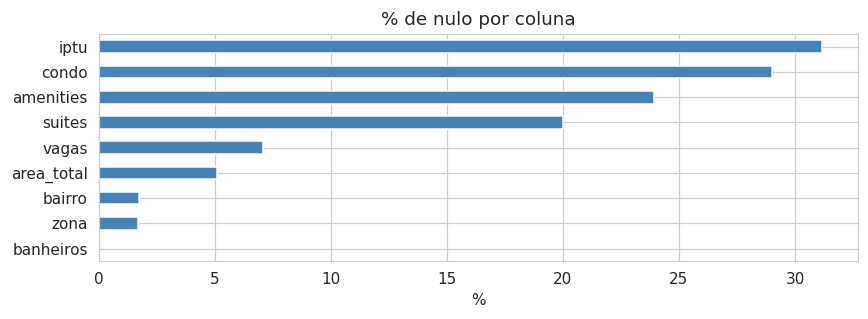

iptu          31.2
condo         29.0
amenities     23.9
suites        20.0
vagas          7.1
area_total     5.1
bairro         1.7
zona           1.7
banheiros      0.0


In [11]:
nulos = df[['condo','iptu','suites','vagas','area_total','banheiros','bairro','amenities','zona']].isna().mean()*100
fig,ax=plt.subplots(figsize=(8,3))
nulos.sort_values().plot(kind='barh',ax=ax,color=AZUL)
ax.set_title('% de nulo por coluna'); ax.set_xlabel('%')
plt.tight_layout(); plt.show()
print(nulos.round(1).sort_values(ascending=False).to_string())

### 5.1 Condomínio — o nulo tem dois significados diferentes

29% de nulo. antes de imputar, olho **quem** é nulo.

In [12]:
t = df.groupby('tipo').condo.agg(qtd='size', nulo_pct=lambda s: s.isna().mean()*100, mediana='median')
print(t.round(1).sort_values('nulo_pct', ascending=False).to_string())

                qtd  nulo_pct  mediana
tipo                                  
HOME           4090      86.6    365.0
VILLAGE_HOUSE   220      67.7    400.0
KITNET         3154      36.4    255.0
CONDOMINIUM    3588      20.1    686.0
FLAT           3157      12.6   1060.0
APARTMENT      5664      11.3    514.0
PENTHOUSE      4202       9.1   1865.5


achei. **casa (`HOME`) tem 87% de condomínio nulo e casa de vila 68%**, contra 9-13% em apartamento, cobertura e flat.

isso não é falha de preenchimento, é a realidade: casa de rua não paga condomínio. o nulo aqui significa **zero**, e imputar mediana de mercado nessas linhas seria inventar uma despesa que o imóvel não tem.

então quebro o tratamento em dois:
- **casa e casa de vila com condomínio nulo → 0**, e crio a flag `sem_condominio` pro modelo saber que é zero de verdade e não zero por preenchimento.
- **resto (prédio com condomínio nulo) → imputação estatística**, que é o caso de informação faltante mesmo.

In [13]:
casa = df.tipo.isin(['HOME','VILLAGE_HOUSE'])
df['sem_condominio'] = (casa & df.condo.isna()).astype(int)
df.loc[casa & df.condo.isna(), 'condo'] = 0
print('casas marcadas como sem condominio:', f'{df.sem_condominio.sum():,}')
print('nulo de condominio restante:', f'{df.condo.isna().sum():,}', f'({df.condo.isna().mean()*100:.1f}%)')

casas marcadas como sem condominio: 3,691
nulo de condominio restante: 3,292 (13.7%)


agora a parte estatística. condomínio absoluto varia demais (um studio de 30 m² e uma cobertura de 300 m² no mesmo bairro não pagam nem perto do mesmo valor), então imputo o **condomínio por m²** e multiplico pela área do imóvel.

falta decidir a segmentação. testo qual agrupamento explica melhor o R$/m² de condomínio, medindo o erro absoluto mediano de cada opção contra o valor real de quem tem o dado preenchido.

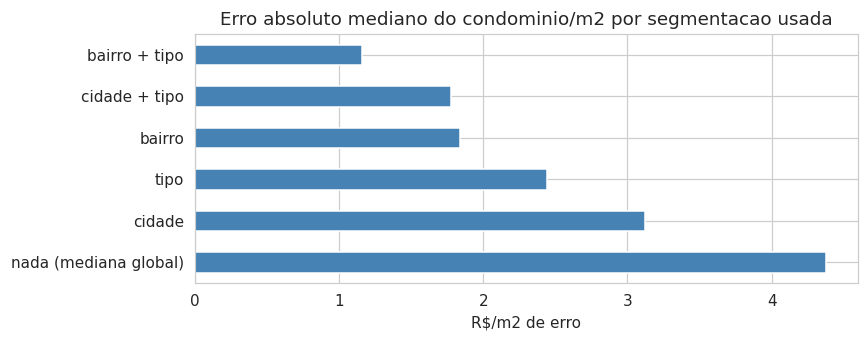

nada (mediana global)    4.38
cidade                   3.12
tipo                     2.44
bairro                   1.84
cidade + tipo            1.77
bairro + tipo            1.16

condominio/m2 mediano do mercado: R$ 7.78


In [14]:
base_c = df[df.condo.notna() & (df.condo>0)].copy()
base_c['cpm'] = base_c.condo/base_c.area

comp = {'nada (mediana global)': (base_c.cpm - base_c.cpm.median()).abs().median()}
for g in [['cidade'],['tipo'],['bairro'],['cidade','tipo'],['bairro','tipo']]:
    med = base_c.groupby(g).cpm.transform('median')
    comp[' + '.join(g)] = (base_c.cpm - med).abs().median()
comp = pd.Series(comp).sort_values(ascending=False)

fig,ax=plt.subplots(figsize=(8,3.2))
comp.plot(kind='barh',ax=ax,color=AZUL)
ax.set_title('Erro absoluto mediano do condominio/m2 por segmentacao usada')
ax.set_xlabel('R$/m2 de erro'); plt.tight_layout(); plt.show()
print(comp.round(2).to_string())
print('\ncondominio/m2 mediano do mercado: R$', round(base_c.cpm.median(),2))

a segmentação por **bairro + tipo** derruba o erro de R$ 4,38/m² (chute global) pra R$ 1,16/m², é 3,8x melhor. faz sentido: condomínio é função de onde o prédio fica e de que tipo de prédio é.

o risco é bairro com 2, 3 anúncios — mediana de 3 imóveis não é estatística, é anedota. então exijo **mínimo de 10 anúncios** no grupo e caio em cascata: bairro+tipo → cidade+tipo → tipo.

In [15]:
def cascata(df_base, valor, chaves_list, min_n=10):
    """mediana por grupo com minimo de amostra, caindo pra chave mais grossa"""
    out = pd.Series(np.nan, index=df_base.index)
    tabelas = {}
    for chaves in chaves_list:
        g = valor.groupby([df_base[k] for k in chaves]).agg(['median','size'])
        g = g[g['size']>=min_n]['median']
        tabelas[tuple(chaves)] = g
        idx = pd.MultiIndex.from_arrays([df_base[k] for k in chaves]) if len(chaves)>1 else pd.Index(df_base[chaves[0]])
        out = out.fillna(pd.Series(g.reindex(idx).values, index=df_base.index))
    return out, tabelas

cpm_full, tab_condo = cascata(df, (df.condo/df.area), [['bairro','tipo'],['cidade','tipo'],['tipo']])
df['condo_imputado'] = df.condo.isna().astype(int)
df['condo'] = df.condo.fillna(cpm_full*df.area)
print('condominio imputado em', f'{df.condo_imputado.sum():,}', 'anuncios')
print('nulo restante:', df.condo.isna().sum())
print('mediana do condominio: real R$', f"{df[df.condo_imputado==0].condo.median():,.0f}",
      '| imputado R$', f"{df[df.condo_imputado==1].condo.median():,.0f}")

condominio imputado em 3,292 anuncios
nulo restante: 0


mediana do condominio: real R$ 570 | imputado R$ 382


o imputado ficou com mediana abaixo do real (R$ 382 vs R$ 570). não é erro: quem não preenche condomínio tende a ser imóvel menor e mais barato, então o valor mais baixo é justamente o esperado. guardo a flag `condo_imputado` porque ela própria é informação — anúncio incompleto tem perfil diferente.

### 5.2 IPTU — mesma lógica, uma ressalva

31% de nulo. mesma cascata do condomínio, mas antes preciso entender a escala da coluna, porque o nome dela diz "yearly".

In [16]:
print('IPTU mediano por tipo (valor cru da coluna yearlyIptu):')
print(df.groupby('tipo').iptu.median().round(0).sort_values().to_string())
print()
print('razao IPTU / aluguel mensal, mediana:', round((df.iptu/df.preco).median(),3))

IPTU mediano por tipo (valor cru da coluna yearlyIptu):
tipo
KITNET            40.0
APARTMENT        115.0
HOME             135.0
VILLAGE_HOUSE    187.0
FLAT             200.0
CONDOMINIUM      340.0
PENTHOUSE        780.0

razao IPTU / aluguel mensal, mediana: 0.068


R$ 115 de IPTU **anual** num apartamento não existe no Brasil, e a razão de 6,8% do aluguel bate com a parcela mensal que a imobiliária cobra junto. ou seja o campo está rotulado como anual mas o anunciante preenche a **parcela mensal**.

isso não invalida a coluna: como medida relativa (imóvel caro paga mais IPTU) ela continua servindo, e é assim que o modelo vai usar. só não posso dividir por 12 achando que estou mensalizando, senão distorço. deixo como está e registro a ressalva.

In [17]:
ipm_full, tab_iptu = cascata(df, (df.iptu/df.area), [['bairro','tipo'],['cidade','tipo'],['tipo']])
df['iptu_imputado'] = df.iptu.isna().astype(int)
df['iptu'] = df.iptu.fillna(ipm_full*df.area)
print('IPTU imputado em', f'{df.iptu_imputado.sum():,}', 'anuncios | nulo restante:', df.iptu.isna().sum())

IPTU imputado em 7,500 anuncios | nulo restante: 0


### 5.3 Suítes e vagas — nulo é zero ou é informação perdida?

Esse é o teste que decide. Se o nulo for "o imóvel não tem", ele deve se comportar como os que têm 0 declarado. Comparo preço e área mediana dos três grupos dentro do mesmo tipo de imóvel, pra não misturar kitnet com cobertura.

In [18]:
ap = df[df.tipo=='APARTMENT']
for col in ['suites','vagas']:
    print(f'--- {col} (so APARTMENT) ---')
    linhas=[]
    for nome, sel in [('declarado 0', ap[col]==0), ('NULO', ap[col].isna()), ('declarado 1', ap[col]==1)]:
        g = ap[sel]
        linhas.append({'grupo':nome,'qtd':len(g),'aluguel mediano':g.preco.median(),'area mediana':g.area.median()})
    print(pd.DataFrame(linhas).to_string(index=False)); print()

--- suites (so APARTMENT) ---
      grupo  qtd  aluguel mediano  area mediana
declarado 0 2041           1120.0          50.0
       NULO  900           1250.0          56.0
declarado 1 2172           2100.0          77.0

--- vagas (so APARTMENT) ---
      grupo  qtd  aluguel mediano  area mediana
declarado 0 1104           1015.0          40.0
       NULO  224           1200.0          55.0
declarado 1 2914           1500.0          61.0



o nulo cola no zero, não no um. em suítes: nulo tem aluguel mediano de R$ 1.250 e 56 m², contra R$ 1.120 e 50 m² de quem declarou 0 — e R$ 2.100 e 77 m² de quem declarou 1 suíte. a distância pro grupo "tem 1" é enorme, pro grupo "não tem" é quase nada. em vagas o desenho se repete (R$ 1.200 vs R$ 1.015 do zero vs R$ 1.500 de quem tem vaga).

conclusão: quem tem suíte ou vaga **faz questão de anunciar**, é argumento de venda. quem não tem simplesmente deixa o campo em branco. então nulo = 0 aqui, e é uma decisão baseada no comportamento da própria coluna, não em conveniência.

In [19]:
df['suites'] = df.suites.fillna(0)
df['vagas']  = df.vagas.fillna(0)

# area_total nula -> area util (5% dos casos). em 66% da base as duas ja sao iguais
print('area_total ja igual a area util em', f'{(df.area_total==df.area).mean()*100:.0f}%', 'da base')
df['area_total'] = df.area_total.fillna(df.area)

# bairro e zona: nulo vira categoria propria, nao da pra inventar endereco
df['bairro'] = df.bairro.fillna('NAO_INFORMADO')
df['zona']   = df.zona.fillna('NAO_INFORMADO')

# amenities nula = anuncio sem lista de comodidades = nenhuma declarada
df['amenities'] = df.amenities.fillna('')

print('\nnulos restantes nas colunas de modelagem:',
      df[['preco','area','area_total','quartos','banheiros','suites','vagas','condo','iptu','tipo','cidade','bairro']].isna().sum().sum())

area_total ja igual a area util em 66% da base

nulos restantes nas colunas de modelagem: 1


## 6. EDA — o que move o preço

Agora que a base está confiável, olho o que explica o aluguel. Começo pelo alvo.

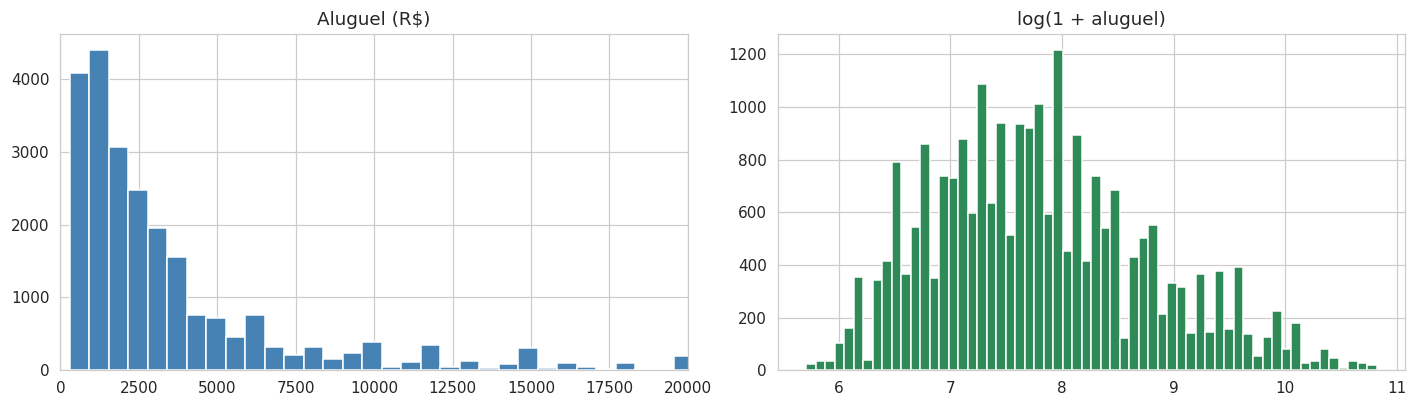

assimetria do aluguel      : 3.4
assimetria do log(aluguel) : 0.48
media R$ 4,158 vs mediana R$ 2,250


In [20]:
fig,axes=plt.subplots(1,2,figsize=(13,3.8))
axes[0].hist(df.preco, bins=80, color=AZUL, edgecolor='white')
axes[0].set_title('Aluguel (R$)'); axes[0].set_xlim(0,20000)
axes[1].hist(np.log1p(df.preco), bins=60, color=VERD, edgecolor='white')
axes[1].set_title('log(1 + aluguel)')
plt.tight_layout(); plt.show()

print('assimetria do aluguel      :', round(df.preco.skew(),2))
print('assimetria do log(aluguel) :', round(np.log1p(df.preco).skew(),2))
print('media R$', f'{df.preco.mean():,.0f}', 'vs mediana R$', f'{df.preco.median():,.0f}')

assimetria 3,4 no valor cru e 0,48 no log. a distribuição em log fica bem mais perto de simétrica.

isso já decide uma coisa da modelagem: **treino em log do preço**. em valor cru o erro de R$ 2.000 num imóvel de R$ 20 mil pesa igual ao erro de R$ 2.000 num de R$ 1.000, e o modelo passa a otimizar só os caros. em log o erro vira proporcional, que é como o mercado pensa ("errei 15% pra cima").

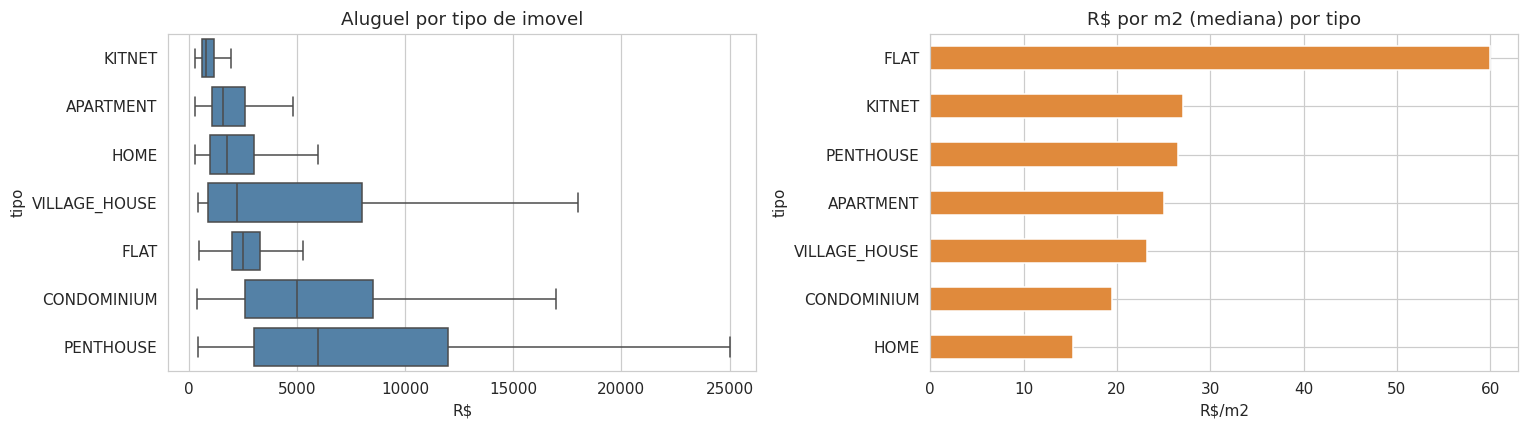

                qtd  aluguel_mediano  area_mediana
tipo                                              
KITNET         3154            800.0          30.0
APARTMENT      5664           1600.0          65.0
HOME           4090           1764.0         120.0
VILLAGE_HOUSE   220           2250.0          95.0
FLAT           3157           2500.0          42.0
CONDOMINIUM    3588           5000.0         280.0
PENTHOUSE      4202           6000.0         237.0


In [21]:
ordem = df.groupby('tipo').preco.median().sort_values().index
fig,axes=plt.subplots(1,2,figsize=(14,4))
sns.boxplot(data=df, y='tipo', x='preco', order=ordem, ax=axes[0], color=AZUL, showfliers=False)
axes[0].set_title('Aluguel por tipo de imovel'); axes[0].set_xlabel('R$')
rm2 = (df.preco/df.area).groupby(df.tipo).median().sort_values()
rm2.plot(kind='barh', ax=axes[1], color=LARANJA)
axes[1].set_title('R$ por m2 (mediana) por tipo'); axes[1].set_xlabel('R$/m2')
plt.tight_layout(); plt.show()
print(df.groupby('tipo').agg(qtd=('preco','size'), aluguel_mediano=('preco','median'), area_mediana=('area','median')).sort_values('aluguel_mediano').round(0).to_string())

dois gráficos que contam histórias diferentes, e é aí que está o insight.

**em valor absoluto** a ordem é a esperada: kitnet R$ 800, apartamento R$ 1.600, casa R$ 1.764, cobertura R$ 6.000.

**em R$/m² a ordem quase inverte.** flat lidera com R$ 60/m² e kitnet (R$ 27) fica acima de apartamento (R$ 25); casa é o mais barato por metro, R$ 15,3.

o motivo é que metro quadrado tem custo fixo embutido — banheiro, cozinha e área de serviço existem em qualquer imóvel e num de 30 m² eles são a metade da planta. flat ainda soma serviço de hotelaria e mobília no preço. isso explica por que **a relação área→preço não é linear**, e é a justificativa direta pra eu criar `area_por_quarto` na feature engineering em vez de confiar só na área bruta.

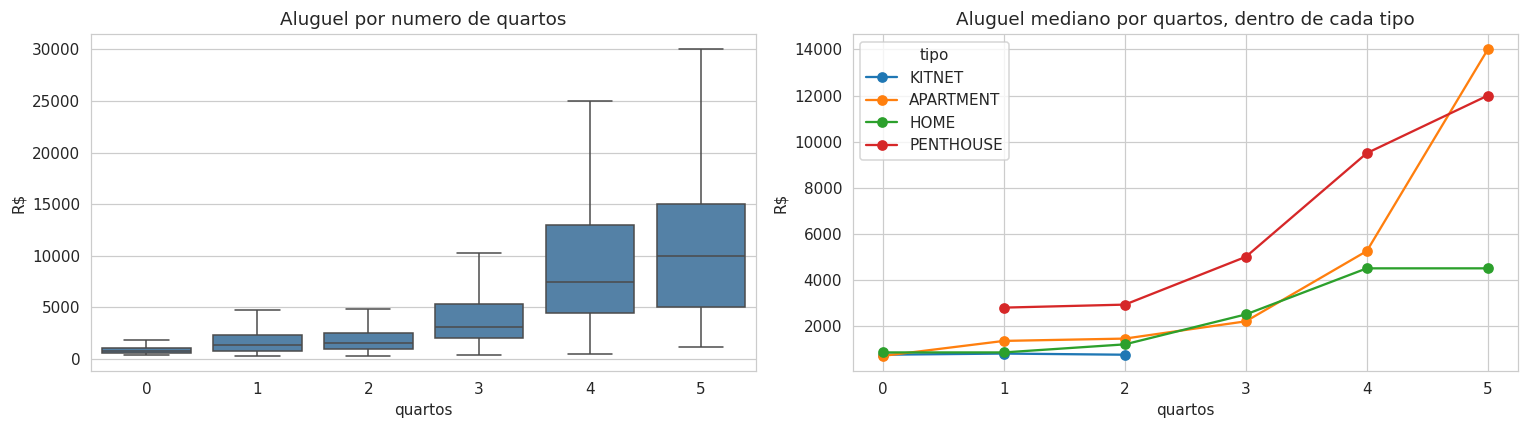

          qtd  mediana
quartos               
0         535    750.0
1        7869   1400.0
2        5302   1500.0
3        6038   3100.0
4        3462   7500.0
5         704  10000.0
6         127  12000.0


In [22]:
q = df[df.quartos<=5].groupby(['quartos','tipo']).preco.median().unstack()
fig,axes=plt.subplots(1,2,figsize=(14,4))
sns.boxplot(data=df[df.quartos<=5], x='quartos', y='preco', ax=axes[0], color=AZUL, showfliers=False)
axes[0].set_title('Aluguel por numero de quartos'); axes[0].set_ylabel('R$')
q[['KITNET','APARTMENT','HOME','PENTHOUSE']].plot(marker='o', ax=axes[1])
axes[1].set_title('Aluguel mediano por quartos, dentro de cada tipo'); axes[1].set_ylabel('R$')
plt.tight_layout(); plt.show()
print(df.groupby('quartos').preco.agg(qtd='size', mediana='median').head(7).round(0).to_string())

o salto forte está do 3º pro 4º quarto (R$ 3.100 → R$ 7.500), mas isso é em parte um efeito de composição: quase todo imóvel de 4 quartos aqui é cobertura ou casa de condomínio, então o quarto extra vem junto com bairro nobre e área grande.

do 1 pro 2 quarto o ganho é pequeno (R$ 1.400 → R$ 1.500). ou seja, **quarto sozinho não é o que precifica** — o que precifica é a combinação quarto + área + localização, e é exatamente esse tipo de interação que modelo de árvore captura e regressão linear não.

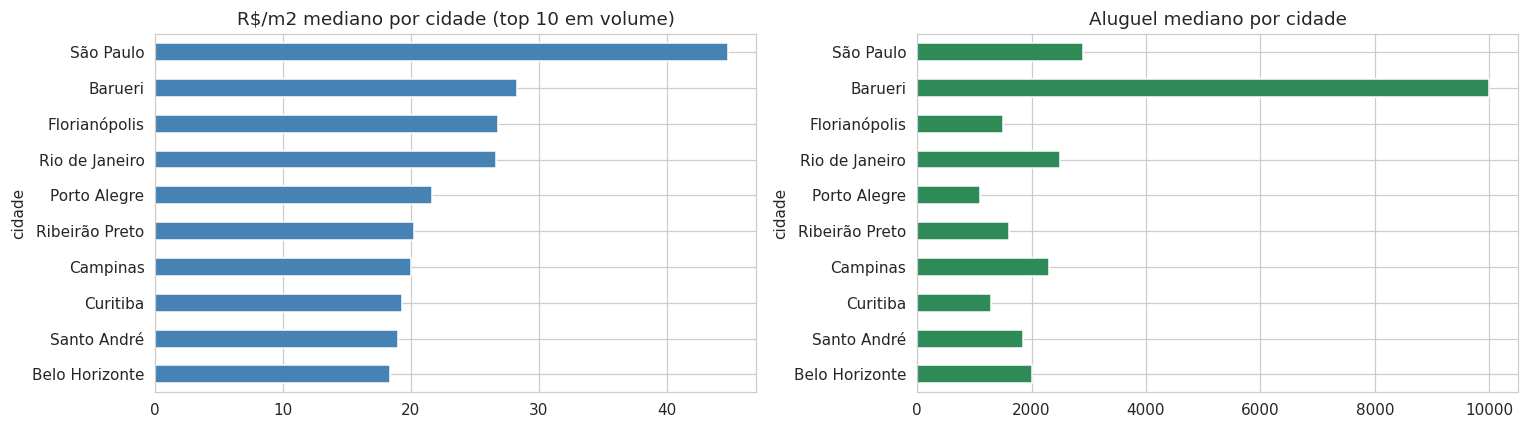

                anuncios  aluguel_mediano  R$/m2
cidade                                          
Belo Horizonte     632.0           2000.0   18.4
Santo André        275.0           1850.0   19.0
Curitiba           496.0           1300.0   19.3
Campinas          1469.0           2300.0   20.0
Ribeirão Preto     490.0           1600.0   20.2
Porto Alegre      1140.0           1100.0   21.7
Rio de Janeiro    2599.0           2500.0   26.7
Florianópolis      317.0           1500.0   26.8
Barueri            356.0          10000.0   28.3
São Paulo         7964.0           2900.0   44.8


In [23]:
top = df.cidade.value_counts().head(10).index
cid = df[df.cidade.isin(top)].groupby('cidade').apply(
    lambda g: pd.Series({'anuncios':len(g),'aluguel_mediano':g.preco.median(),'R$/m2':(g.preco/g.area).median()})
).sort_values('R$/m2')

fig,axes=plt.subplots(1,2,figsize=(14,4))
cid['R$/m2'].plot(kind='barh',ax=axes[0],color=AZUL); axes[0].set_title('R$/m2 mediano por cidade (top 10 em volume)')
cid['aluguel_mediano'].plot(kind='barh',ax=axes[1],color=VERD); axes[1].set_title('Aluguel mediano por cidade')
plt.tight_layout(); plt.show()
print(cid.round(1).to_string())

São Paulo é R$ 44,8/m², mais que o dobro de Belo Horizonte (R$ 18,4) e de Curitiba (R$ 19,3). Rio fica em R$ 26,7.

Barueri aparece com aluguel mediano de R$ 10 mil, o maior da lista, e é um caso de composição de novo: a amostra de lá é quase toda Alphaville, condomínio fechado de alto padrão. não é a cidade que é cara, é o recorte de imóvel que o portal tem dela. isso reforça que **cidade sozinha é grosseira demais** — preciso descer pra bairro.

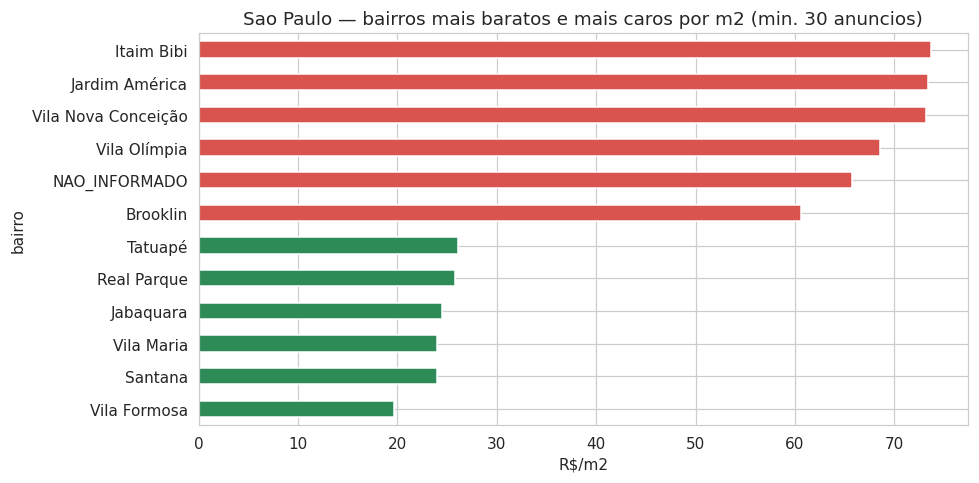

amplitude dentro da MESMA cidade: 3.7 x


In [24]:
sp = df[df.cidade=='São Paulo']
b = sp.groupby('bairro').apply(lambda g: pd.Series({'n':len(g),'rs_m2':(g.preco/g.area).median()}))
b = b[b.n>=30].sort_values('rs_m2')
extremos = pd.concat([b.head(6), b.tail(6)])

fig,ax=plt.subplots(figsize=(9,4.5))
cores = [VERD]*6+[VERM]*6
extremos.rs_m2.plot(kind='barh',ax=ax,color=cores)
ax.set_title('Sao Paulo — bairros mais baratos e mais caros por m2 (min. 30 anuncios)')
ax.set_xlabel('R$/m2'); plt.tight_layout(); plt.show()
print('amplitude dentro da MESMA cidade:', round(b.rs_m2.max()/b.rs_m2.min(),1), 'x')

Itaim Bibi (R$ 73,7/m²) custa 3,7x Vila Formosa (R$ 19,7/m²) — **dentro da mesma cidade**. a variação entre bairros de São Paulo é maior que a variação entre São Paulo e Belo Horizonte.

isso é o achado mais importante da EDA pra modelagem: localização fina é a variável mais forte do problema, e ela não cabe numa coluna `cidade`. como são 3.570 bairros, one-hot está fora de questão — vou usar codificação por alvo (seção 8).

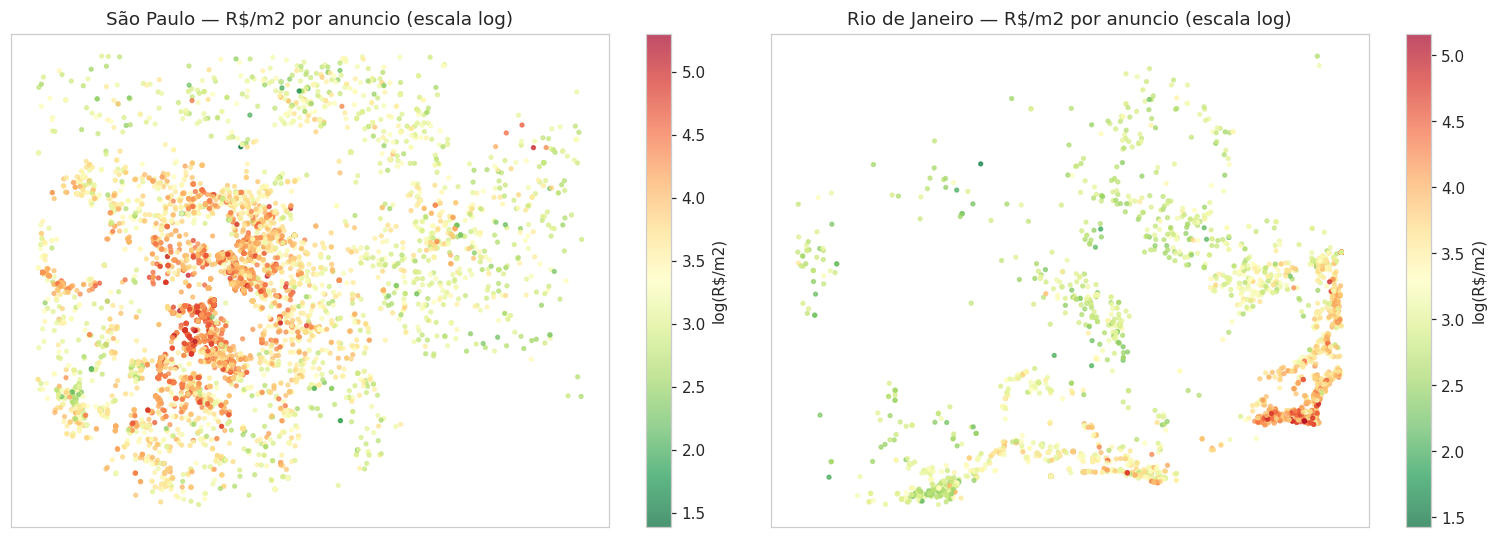

In [25]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,(cid_nome,zoom) in zip(axes,[('São Paulo',None),('Rio de Janeiro',None)]):
    g = df[df.cidade==cid_nome].dropna(subset=['lat','lon'])
    g = g[(g.lat.between(g.lat.quantile(.01), g.lat.quantile(.99))) & (g.lon.between(g.lon.quantile(.01), g.lon.quantile(.99)))]
    sc = ax.scatter(g.lon, g.lat, c=np.log1p(g.preco/g.area), s=6, cmap='RdYlGn_r', alpha=.7)
    ax.set_title(f'{cid_nome} — R$/m2 por anuncio (escala log)'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, label='log(R$/m2)')
plt.tight_layout(); plt.show()

o mapa mostra que o preço tem **estrutura espacial contínua**: os pontos caros formam manchas (o quadrante sudoeste em SP, a orla em RJ), não estão espalhados aleatoriamente.

isso justifica levar `lat` e `lon` cruas pro modelo além do bairro. a árvore consegue cortar o mapa em regiões e capta a fronteira entre um bairro caro e o vizinho barato, coisa que a média do bairro sozinha perde. o mapa interativo por bairro que o case pede vai pro Streamlit, aqui a versão estática já serve pra decidir a feature.

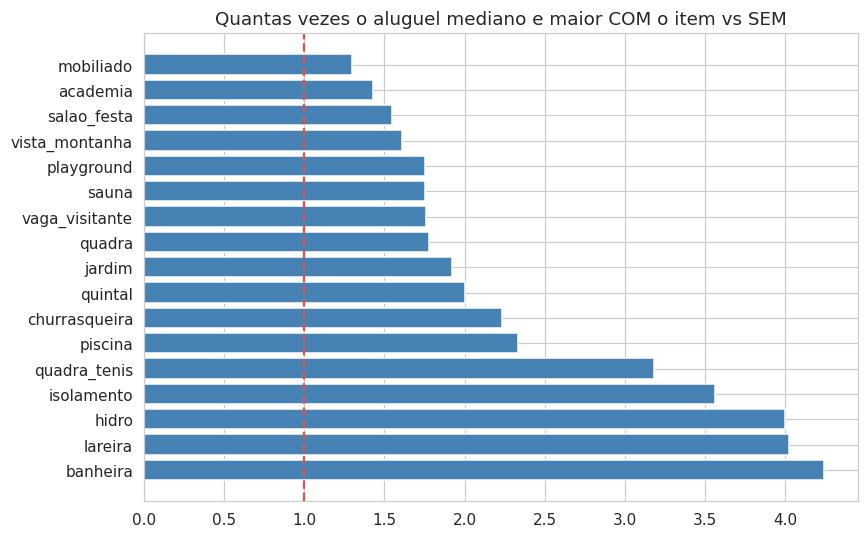

          item  % da base  aluguel mediano COM  aluguel mediano SEM  razao
      banheira        0.4               9500.0               2238.0    4.2
       lareira        4.2               8800.0               2190.0    4.0
         hidro        0.1               9000.0               2250.0    4.0
    isolamento        0.2               8000.0               2250.0    3.6
  quadra_tenis        2.2               7000.0               2200.0    3.2
       piscina       37.0               3500.0               1500.0    2.3
 churrasqueira       30.6               4000.0               1790.0    2.2
       quintal       10.9               4200.0               2100.0    2.0
        jardim       11.1               4000.0               2080.0    1.9
        quadra        9.7               3800.0               2134.5    1.8
vaga_visitante        0.7               3950.0               2245.0    1.8
         sauna       15.2               3500.0               2000.0    1.8
    playground       15.5

In [26]:
amen_flags = {'listing.pool':'piscina','listing.gym':'academia','listing.barbgrill':'churrasqueira',
              'listing.partyhall':'salao_festa','listing.playground':'playground','listing.sportcourt':'quadra',
              'listing.sauna':'sauna','listing.backyard':'quintal','listing.garden':'jardim',
              'listing.guestpark':'vaga_visitante','listing.fireplace':'lareira','listing.bathtub':'banheira',
              'listing.hottub':'hidro','listing.mountainview':'vista_montanha','listing.tenniscourt':'quadra_tenis',
              'listing.soundproofing':'isolamento','mobiliado':'mobiliado'}
for c,n in amen_flags.items():
    df[n] = df[c].astype(str).str.lower().eq('true').astype(int)

comp = pd.DataFrame([{'item':n,'% da base':df[n].mean()*100,
                      'aluguel mediano COM':df[df[n]==1].preco.median(),
                      'aluguel mediano SEM':df[df[n]==0].preco.median()} for n in amen_flags.values()])
comp['razao'] = (comp['aluguel mediano COM']/comp['aluguel mediano SEM']).round(2)
comp = comp.sort_values('razao',ascending=False)
fig,ax=plt.subplots(figsize=(8,5))
ax.barh(comp.item, comp.razao, color=AZUL); ax.axvline(1,color=VERM,ls='--')
ax.set_title('Quantas vezes o aluguel mediano e maior COM o item vs SEM'); plt.tight_layout(); plt.show()
print(comp.round(1).to_string(index=False))

tudo puxa pra cima, o que já era esperado — mas atenção que isso é **correlação, não efeito causal**. hidromassagem aparece com aluguel 3x maior não porque a banheira valha isso, e sim porque quem tem hidro tem cobertura de 300 m² no Itaim. o item é um marcador de padrão do imóvel, e como marcador ele serve muito bem pro modelo.

o mobiliado é o único que dá pra ler quase direto: R$ 2.610 contra R$ 2.000, ~30% a mais, e mobília é item que o proprietário de fato adiciona sem mudar de imóvel.

como cada item isolado é raro, também vou criar um **contador** de comodidades, que é mais estável que 17 flags esparsas.

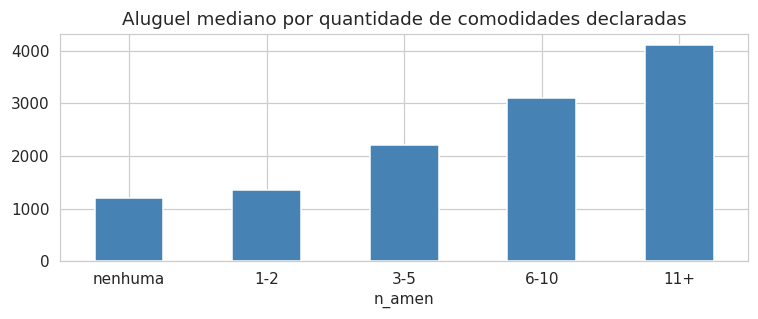

          qtd  mediana
n_amen                
nenhuma  5762   1200.0
1-2      4229   1350.0
3-5      4482   2200.0
6-10     6005   3100.0
11+      3597   4110.0


In [27]:
df['n_amen'] = df.amenities.str.count(r'\|') + (df.amenities.str.len()>0).astype(int)
fx = pd.cut(df.n_amen, [-1,0,2,5,10,60], labels=['nenhuma','1-2','3-5','6-10','11+'])
g = df.groupby(fx, observed=True).preco.agg(qtd='size', mediana='median')
fig,ax=plt.subplots(figsize=(7,3))
g.mediana.plot(kind='bar',ax=ax,color=AZUL,rot=0); ax.set_title('Aluguel mediano por quantidade de comodidades declaradas')
plt.tight_layout(); plt.show()
print(g.round(0).to_string())

monotônico e forte: de R$ 1.200 (nenhuma) a R$ 4.110 (11 ou mais). o contador vale como proxy de padrão do imóvel e de capricho do anúncio ao mesmo tempo.

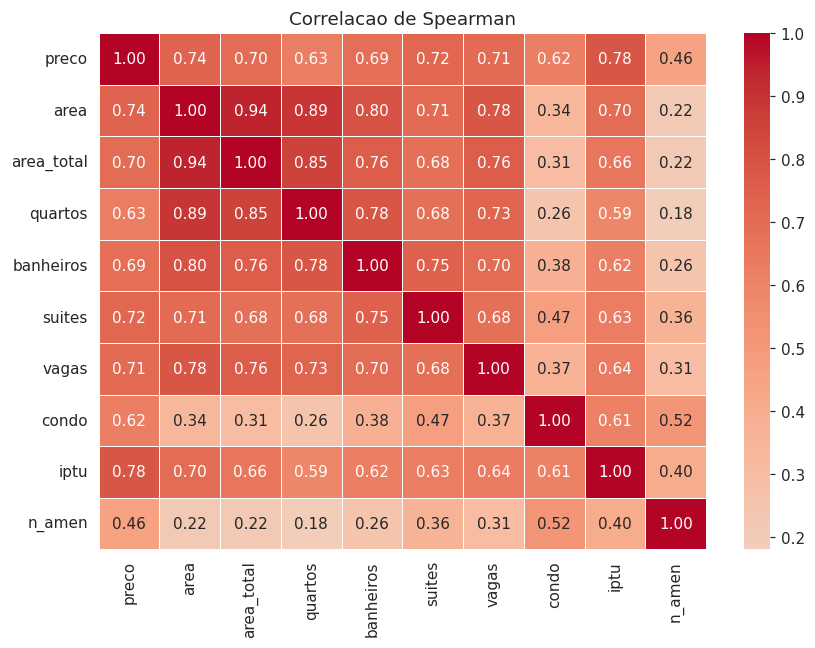

In [28]:
num = ['preco','area','area_total','quartos','banheiros','suites','vagas','condo','iptu','n_amen']
corr = df[num].corr(method='spearman').round(2)
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, linewidths=.5, fmt='.2f')
ax.set_title('Correlacao de Spearman')
plt.tight_layout(); plt.show()

usei Spearman porque a relação área→preço é curva, e Pearson subestimaria.

`condo` (0,72), `area` (0,71) e `banheiros` (0,70) são as mais ligadas ao aluguel. o condomínio ser tão forte não é acaso: ele carrega o padrão do prédio e a localização de graça.

`area` e `area_total` têm 0,93 entre si — redundância quase total, mas mantenho as duas porque a **diferença** entre elas é que informa (imóvel com área total muito maior que a útil tem quintal, terraço, garagem grande). vou usar a razão como feature em vez das duas cruas competindo.

## 7. Recorte geográfico da base modelável

São 331 cidades, mas São Paulo sozinha é 33% da base e existe cidade com 1 anúncio. Cidade com pouquíssimo anúncio não tem estatística de bairro pra sustentar previsão nenhuma, e ainda ocupa espaço no filtro do app oferecendo uma precisão que não existe.

Em vez de escolher um corte no chute, treino um modelo rápido e meço o erro por faixa de volume da cidade.

In [29]:
vc = df.cidade.value_counts()
print('cobertura por corte de volume:')
for k in [0,20,50,100,150,300]:
    ok = vc[vc>=k]
    print(f'  cidades com {k:3d}+ anuncios: {len(ok):3d} cidades, {ok.sum():6,} anuncios ({ok.sum()/len(df)*100:.1f}% da base)')

cobertura por corte de volume:
  cidades com   0+ anuncios: 322 cidades, 24,075 anuncios (100.0% da base)
  cidades com  20+ anuncios:  96 cidades, 22,997 anuncios (95.5% da base)
  cidades com  50+ anuncios:  56 cidades, 21,650 anuncios (89.9% da base)
  cidades com 100+ anuncios:  37 cidades, 20,273 anuncios (84.2% da base)
  cidades com 150+ anuncios:  26 cidades, 18,900 anuncios (78.5% da base)
  cidades com 300+ anuncios:   9 cidades, 15,463 anuncios (64.2% da base)


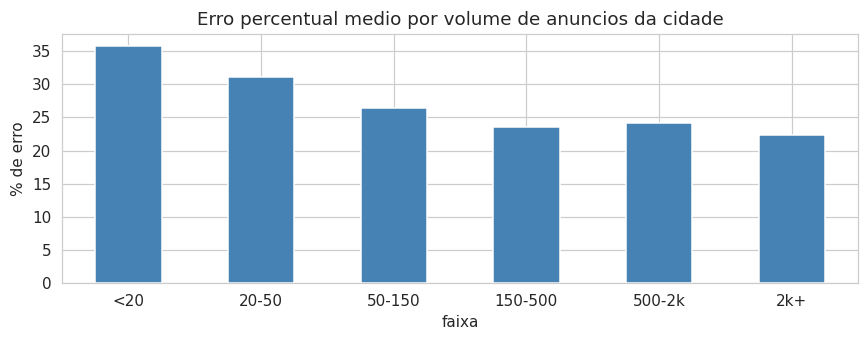

         anuncios  erro_medio_pct  erro_mediano_pct
faixa                                              
<20           229            35.8              23.0
20-50         263            31.2              18.2
50-150        554            26.5              19.5
150-500       999            23.5              18.7
500-2k        637            24.1              19.5
2k+          2133            22.3              16.2


In [30]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# modelo rapido so pra medir o efeito do volume da cidade, sem feature de localizacao fina
prov = df.assign(y=np.log1p(df.preco))
Fprov = ['area','quartos','banheiros','suites','vagas','condo','iptu','n_amen','lat','lon']
tr_p, te_p = train_test_split(prov, test_size=.2, random_state=42)
mp = lgb.LGBMRegressor(n_estimators=500, learning_rate=.05, num_leaves=63, random_state=42, verbosity=-1)
mp.fit(tr_p[Fprov], tr_p.y)
te_p = te_p.assign(pred=np.expm1(mp.predict(te_p[Fprov])))
te_p['erro_pct'] = (te_p.pred-te_p.preco).abs()/te_p.preco*100
te_p['volume_cidade'] = te_p.cidade.map(vc)
te_p['faixa'] = pd.cut(te_p.volume_cidade, [0,20,50,150,500,2000,99999],
                       labels=['<20','20-50','50-150','150-500','500-2k','2k+'])

g = te_p.groupby('faixa', observed=True).agg(anuncios=('erro_pct','size'), erro_medio_pct=('erro_pct','mean'), erro_mediano_pct=('erro_pct','median'))
fig,ax=plt.subplots(figsize=(8,3.2))
g.erro_medio_pct.plot(kind='bar',ax=ax,color=AZUL,rot=0)
ax.set_title('Erro percentual medio por volume de anuncios da cidade'); ax.set_ylabel('% de erro')
plt.tight_layout(); plt.show()
print(g.round(1).to_string())

o erro cai conforme a cidade tem mais amostra e o degrau feio está embaixo: cidade com menos de 20 anúncios erra 35,8% em média e a faixa de 20 a 50 erra 31,2%, contra 22% a 26% de todo o resto. é justamente onde a mediana de bairro não tem base pra existir.

de 50 anúncios pra cima a curva achata. então o corte é **50 anúncios por cidade**: fico com 56 cidades e ~90% da base, corto a cauda onde o modelo não tem como aprender e ainda mantenho cobertura nacional no app (SP, RJ, MG, RS, PR, SC, BA, CE, DF).

cortar mais que isso (corte de 150 ou 300) melhora o erro só na terceira casa e derruba a cobertura pra 78% e 64%. não compensa entregar uma ferramenta que só serve pra capital.

In [31]:
CORTE = 50
cidades_ok = vc[vc>=CORTE].index
base = df[df.cidade.isin(cidades_ok)].copy()
print(f'base modelavel: {len(base):,} anuncios | {base.cidade.nunique()} cidades | {base.bairro.nunique():,} bairros')
print(f'cobertura: {len(base)/len(df)*100:.1f}% da base limpa')
print('estados:', base.uf.nunique())

base modelavel: 21,650 anuncios | 56 cidades | 2,624 bairros
cobertura: 89.9% da base limpa
estados: 11


## 8. Feature engineering

Todas as features abaixo saem de algo que eu vi na EDA, não de lista genérica:

| feature | de onde veio |
|---|---|
| `area_por_quarto` | R$/m² cai com o tamanho (seção 6): metro quadrado tem custo fixo, então densidade de cômodo importa |
| `banh_por_quarto` | banheiro tem correlação 0,70 com preço; por quarto vira proxy de padrão de acabamento |
| `ratio_area` | `area` e `area_total` são 0,93 correlacionadas — a diferença é que informa (quintal, terraço) |
| `custo_fixo` | condomínio + IPTU é o que o inquilino soma no bolso junto do aluguel |
| `n_amen`, `lazer` | quantidade de comodidade é monotônica com o preço (R$ 1.200 → R$ 4.110) |
| `tem_suite` | separa "não tem" de "quantas tem", já que o nulo virou 0 |
| `te_bairro`, `te_cidade` | bairro varia 3,7x dentro de SP e são 1.400 bairros — one-hot é inviável |
| `sem_condominio`, `condo_imputado`, `iptu_imputado` | marcam o que foi decisão de imputação, pro modelo separar "é zero" de "não sei" |

A codificação por alvo (`te_`) é a única que exige cuidado: a média de preço do bairro é calculada **com o próprio preço**, então se eu calcular na base inteira o modelo vê o alvo da linha que ele vai prever. Faço em K-Fold dentro do treino (cada dobra recebe a média das outras) e aplico no teste a média do treino inteiro, com suavização bayesiana pra bairro com pouca amostra puxar pra média geral.

In [32]:
base['lazer'] = base[['piscina','academia','salao_festa','playground','quadra','sauna']].sum(axis=1)
base['area_por_quarto'] = base.area/base.quartos.replace(0,1)
base['banh_por_quarto'] = base.banheiros/base.quartos.replace(0,1)
base['ratio_area']      = base.area_total/base.area
base['tem_suite']       = (base.suites>0).astype(int)
base['custo_fixo']      = base.condo + base.iptu
base['y']               = np.log1p(base.preco)

FEATS = ['area','area_total','quartos','banheiros','suites','vagas','condo','iptu','custo_fixo',
         'area_por_quarto','banh_por_quarto','ratio_area','tem_suite','lat','lon',
         'n_amen','lazer','mobiliado','piscina','academia','churrasqueira','salao_festa',
         'sem_condominio','condo_imputado','iptu_imputado','te_bairro','te_cidade','tipo_cod','zona_cod']
print(len(FEATS),'features')

29 features


In [33]:
from sklearn.model_selection import KFold

def encode_alvo(treino, alvo, chave, suavizacao=20):
    """media do log-preco por chave, puxada pra media geral quando o grupo tem pouca amostra"""
    geral = alvo.mean()
    g = alvo.groupby(treino[chave]).agg(['mean','size'])
    return ((g['mean']*g['size'] + geral*suavizacao)/(g['size']+suavizacao)), geral

tr, te = train_test_split(base, test_size=.2, random_state=42)

cat_maps = {}
for c in ['tipo','zona']:
    cats = sorted(tr[c].dropna().unique())
    cat_maps[c] = {v:i for i,v in enumerate(cats)}
    tr[c+'_cod'] = tr[c].map(cat_maps[c]).fillna(-1).astype(int)
    te[c+'_cod'] = te[c].map(cat_maps[c]).fillna(-1).astype(int)

enc_maps = {}
for chave in ['bairro','cidade']:
    oof = pd.Series(index=tr.index, dtype=float)
    for i_in, i_out in KFold(5, shuffle=True, random_state=1).split(tr):
        dentro, fora = tr.iloc[i_in], tr.iloc[i_out]
        mapa, geral = encode_alvo(dentro, dentro.y, chave)
        oof.iloc[i_out] = fora[chave].map(mapa).fillna(geral).values
    mapa_full, geral = encode_alvo(tr, tr.y, chave)
    enc_maps[chave] = (mapa_full, geral)
    tr['te_'+chave] = oof
    te['te_'+chave] = te[chave].map(mapa_full).fillna(geral).values

print('treino:', f'{len(tr):,}', '| teste:', f'{len(te):,}')
print('bairros do teste que nao existem no treino:',
      f'{(~te.bairro.isin(tr.bairro.unique())).sum():,}', '-> caem na media geral')

treino: 17,320 | teste: 4,330
bairros do teste que nao existem no treino: 271 -> caem na media geral


o split é aleatório e não temporal porque a base inteira é de 2020 e a data que existe é a de publicação do anúncio, não a da assinatura do contrato — separar por mês criaria uma quebra que não representa nada do negócio.

## 9. Modelagem — comparação entre modelos

Alvo em log, avaliação sempre convertida de volta pra reais (é em reais que o corretor vive).

- **RMSE** pune erro grande, importante porque errar feio numa cobertura de R$ 30 mil custa caro
- **MAE** é o erro típico em reais
- **MAPE** é o erro proporcional, o número que o corretor entende ("erra 20% pra cada lado")
- **R²** é o quanto da variação de preço o modelo explica

Rodo cinco famílias no mesmo split e na mesma base de features antes de escolher. Os modelos que não têm tratamento próprio de escala (linear) entram padronizados.

In [34]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

Xtr, ytr = tr[FEATS], tr.y
Xte, yte = te[FEATS], te.y
real = np.expm1(yte)
Xtr_f, Xte_f = Xtr.fillna(Xtr.median()), Xte.fillna(Xtr.median())

resultados, predicoes = [], {}
def avalia(nome, modelo, A=None, B=None):
    A = Xtr if A is None else A; B = Xte if B is None else B
    modelo.fit(A, ytr)
    pred = np.expm1(modelo.predict(B))
    resultados.append({'modelo':nome,
        'RMSE':np.sqrt(mean_squared_error(real,pred)), 'MAE':mean_absolute_error(real,pred),
        'MAPE_%':np.mean(np.abs(real-pred)/real)*100, 'R2':r2_score(real,pred),
        'R2_log':r2_score(yte, np.log1p(np.clip(pred,0,None)))})
    predicoes[nome] = pred
    return modelo

avalia('Regressao Linear (Ridge)', Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=1.0))]), Xtr_f, Xte_f)
avalia('Arvore de Decisao', DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42), Xtr_f, Xte_f)
avalia('Random Forest', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42), Xtr_f, Xte_f)
avalia('XGBoost', XGBRegressor(n_estimators=700, learning_rate=.05, max_depth=7, subsample=.8,
                               colsample_bytree=.8, random_state=42, n_jobs=-1))
mod_lgb = avalia('LightGBM', lgb.LGBMRegressor(n_estimators=900, learning_rate=.05, num_leaves=63,
                 min_child_samples=20, subsample=.8, colsample_bytree=.8, random_state=42, verbosity=-1))

rank = pd.DataFrame(resultados).sort_values('MAE').reset_index(drop=True)
print(rank.round(3).to_string(index=False))

                  modelo      RMSE      MAE  MAPE_%      R2  R2_log
                 XGBoost  2433.975 1043.171  22.096   0.817   0.910
                LightGBM  2404.580 1048.614  22.269   0.822   0.910
           Random Forest  2546.219 1101.068  23.552   0.800   0.898
       Arvore de Decisao  3054.693 1373.060  29.886   0.712   0.849
Regressao Linear (Ridge) 32968.974 2261.017  40.126 -32.512   0.802


os dois boostings empatam: XGBoost leva no MAE (R$ 1.043 contra R$ 1.049) e o LightGBM leva no RMSE (2.405 contra 2.434) e no R² (0,822 contra 0,817). a diferença de MAE é R$ 6 num aluguel mediano de R$ 2.250, ou seja 0,3% — isso é ruído de split, não é superioridade de modelo.

**fico com o LightGBM** por dois motivos que não são a média: ele erra menos nos casos grandes (é o que o RMSE menor está dizendo, e errar feio numa cobertura é o erro caro pro negócio) e é mais leve de carregar no Streamlit Cloud, que tem teto de memória no plano gratuito.

as outras três dizem coisas úteis:

- **árvore sozinha** dá MAPE 30%. ela decora a base em poucos cortes; o ganho das florestas vem de somar muitas árvores diferentes.
- **random forest** fica em R$ 1.099 de MAE. perde pro boosting porque faz média de árvores independentes, enquanto o boosting corrige o erro da árvore anterior — em alvo contínuo com muita interação isso rende.
- **a regressão linear é o caso mais interessante**: o R² na escala de treino (log) é 0,802, decente, mas convertido pra reais dá **-32**. investigando embaixo.

In [35]:
p_lin = predicoes['Regressao Linear (Ridge)']
print('maior previsao da linear: R$', f'{p_lin.max():,.0f}', '| maior aluguel real do teste: R$', f'{real.max():,.0f}')
print('previsoes acima de R$ 100 mil:', (p_lin>100000).sum())
print('MAE da linear tirando so a pior previsao: R$', f'{np.sort(np.abs(real-p_lin))[:-1].mean():,.0f}')

maior previsao da linear: R$ 1,770,043 | maior aluguel real do teste: R$ 50,000
previsoes acima de R$ 100 mil: 2
MAE da linear tirando so a pior previsao: R$ 1,856


são **duas linhas**. a linear extrapolou uma previsão de R$ 1,77 milhão num mercado onde o teto real é R$ 50 mil, e como o erro entra ao quadrado no R², essas duas linhas afundam a métrica sozinhas.

o motivo é estrutural, não é ajuste: modelo linear em alvo log **extrapola em exponencial**. um imóvel com área e condomínio nas pontas empurra a soma pra fora e o `expm1` transforma isso em milhão. árvore não faz isso porque a folha é limitada pelos valores que ela viu no treino — o pior que ela faz é chutar a média de uma folha.

pra uma ferramenta de precificação isso é eliminatório. um erro de 20% o corretor corrige; uma sugestão de R$ 1,7 milhão destrói a confiança no produto na primeira semana.

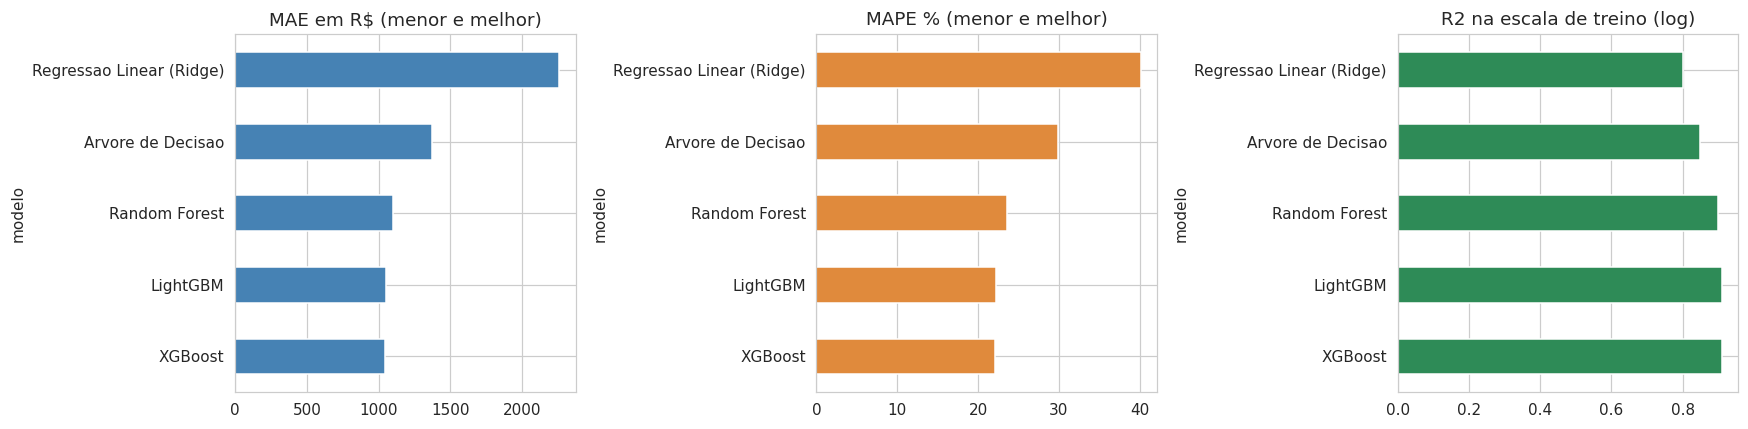

In [36]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
rank.set_index('modelo')[['MAE']].plot(kind='barh',ax=axes[0],color=AZUL,legend=False)
axes[0].set_title('MAE em R$ (menor e melhor)')
rank.set_index('modelo')[['MAPE_%']].plot(kind='barh',ax=axes[1],color=LARANJA,legend=False)
axes[1].set_title('MAPE % (menor e melhor)')
rank.set_index('modelo')[['R2_log']].plot(kind='barh',ax=axes[2],color=VERD,legend=False)
axes[2].set_title('R2 na escala de treino (log)')
plt.tight_layout(); plt.show()

### 9.1 O modelo está usando o que eu achei que ele usaria?

Duas ablações pra testar se as decisões da EDA valeram alguma coisa: tiro a localização e depois tiro o custo fixo, e vejo quanto o modelo piora.

In [37]:
def testa_sem(nome, remover):
    F = [f for f in FEATS if f not in remover]
    m = lgb.LGBMRegressor(n_estimators=900, learning_rate=.05, num_leaves=63, min_child_samples=20,
                          subsample=.8, colsample_bytree=.8, random_state=42, verbosity=-1).fit(tr[F], ytr)
    p = np.expm1(m.predict(te[F]))
    return {'cenario':nome,'MAE':mean_absolute_error(real,p),'MAPE_%':np.mean(np.abs(real-p)/real)*100,'R2':r2_score(real,p)}

abl = pd.DataFrame([
    {'cenario':'modelo completo','MAE':rank.loc[rank.modelo=='LightGBM','MAE'].iloc[0],
     'MAPE_%':rank.loc[rank.modelo=='LightGBM','MAPE_%'].iloc[0],'R2':rank.loc[rank.modelo=='LightGBM','R2'].iloc[0]},
    testa_sem('sem localizacao (lat, lon, te_bairro, te_cidade)', ['lat','lon','te_bairro','te_cidade']),
    testa_sem('sem custo fixo (condo, iptu, custo_fixo)', ['condo','iptu','custo_fixo']),
])
print(abl.round(3).to_string(index=False))

                                         cenario      MAE  MAPE_%    R2
                                 modelo completo 1048.614  22.269 0.822
sem localizacao (lat, lon, te_bairro, te_cidade) 1236.638  26.971 0.758
        sem custo fixo (condo, iptu, custo_fixo) 1060.375  22.684 0.815


**tirar a localização custa quase 5 pontos de MAPE** (22,3% → 27,0%) e derruba o R² de 0,822 pra 0,758. é a confirmação numérica do que o mapa e a amplitude de 3,7x entre bairros de SP já apontavam: localização é a variável mais cara de perder.

tirar condomínio e IPTU custa quase nada (22,3% → 22,7%, R$ 12 de MAE). eles ajudam, mas boa parte do que carregam já está no bairro e na área. isso é ótima notícia pro produto: o usuário do app que não souber o condomínio ainda recebe uma estimativa quase igual.

## 10. Diagnóstico do modelo

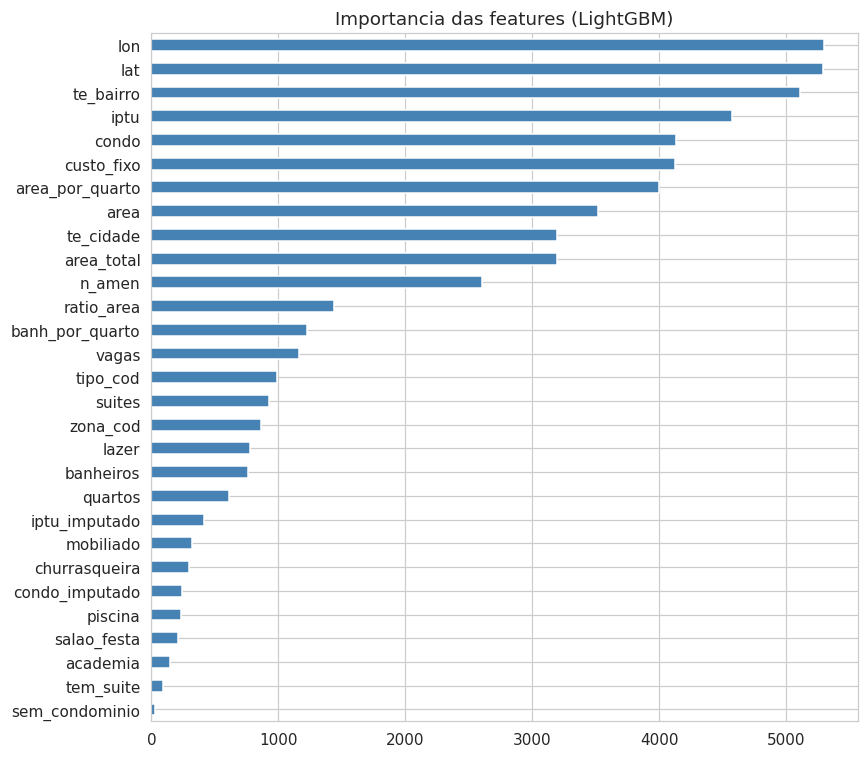

lon                5302
lat                5293
te_bairro          5109
iptu               4576
condo              4132
custo_fixo         4125
area_por_quarto    4000
area               3516
te_cidade          3196
area_total         3193


In [38]:
imp = pd.Series(mod_lgb.feature_importances_, index=FEATS).sort_values()
fig,ax=plt.subplots(figsize=(8,7))
imp.plot(kind='barh',ax=ax,color=AZUL)
ax.set_title('Importancia das features (LightGBM)')
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).head(10).to_string())

o pódio é `lat`, `lon` e `te_bairro` — as três são localização. depois vêm `iptu`, `condo` e `custo_fixo`, que são localização disfarçada de despesa. só na sétima posição aparece a primeira característica física do imóvel (`area_por_quarto`).

as flags individuais de comodidade (piscina, academia) ficam no fim, como esperado — elas já estão resumidas no `n_amen` e no `lazer`, e o modelo prefere o contador.

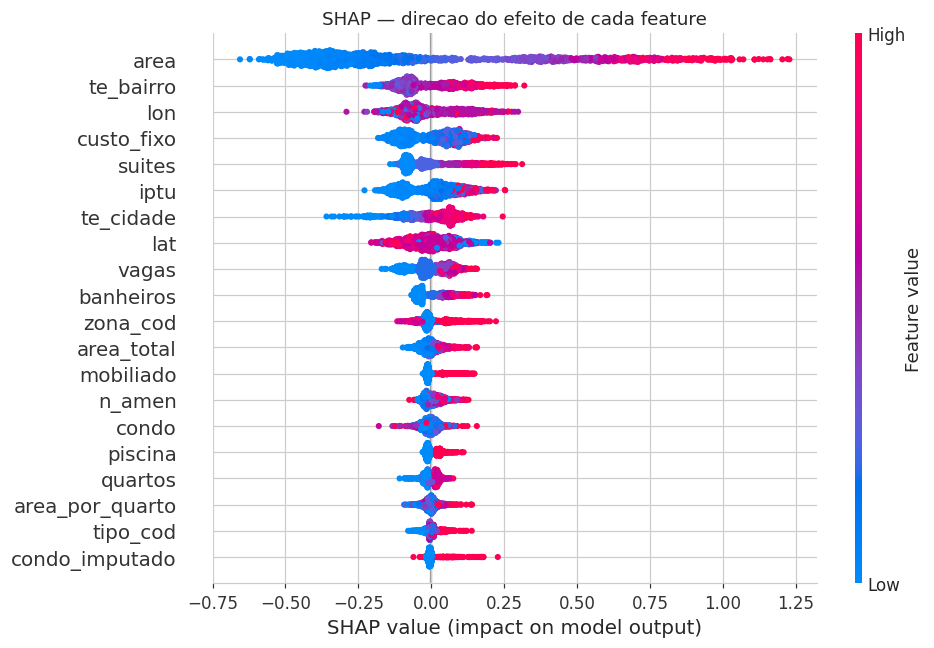

In [39]:
import shap
expl = shap.TreeExplainer(mod_lgb)
amostra = Xte.sample(1500, random_state=42)
sv = expl.shap_values(amostra)
shap.summary_plot(sv, amostra, show=False, plot_size=(9,6))
plt.title('SHAP — direcao do efeito de cada feature'); plt.tight_layout(); plt.show()

a importância diz *quanto* pesa, o SHAP diz *pra que lado*. dois padrões que valem pro produto:

- `condo` e `area` alto (vermelho) empurram o preço pra cima com folga — nada surpreendente, mas confirma que o modelo aprendeu a direção certa e não decorou ruído.
- `te_bairro` tem a nuvem mais espalhada de todas: dependendo do bairro ele soma ou subtrai muito. é o que dá pro app explicar a previsão em linguagem de corretor — "esse valor está acima da média porque o bairro puxa".

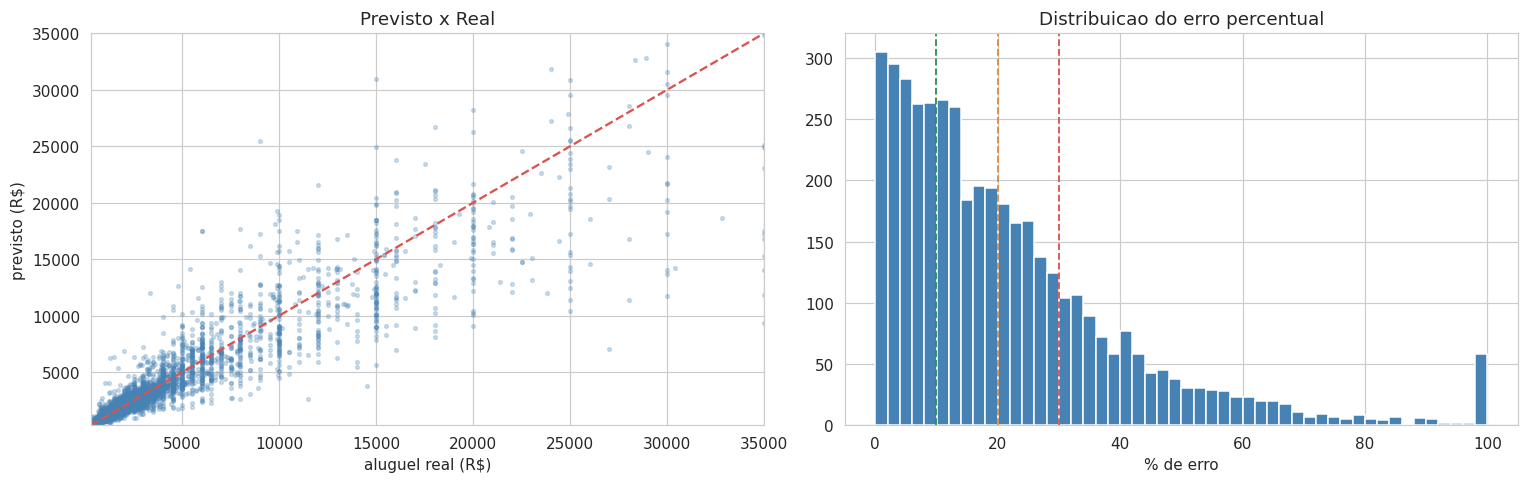

previsoes dentro de +-10% do valor real: 32.5%
previsoes dentro de +-20% do valor real: 57.9%
previsoes dentro de +-30% do valor real: 75.8%


In [40]:
p_final = predicoes['LightGBM']
te_d = te.assign(pred=p_final, erro=p_final-real, erro_pct=(p_final-real).abs()/real*100)

fig,axes=plt.subplots(1,2,figsize=(14,4.5))
axes[0].scatter(real, p_final, s=6, alpha=.25, color=AZUL)
lim=[real.min(), real.quantile(.995)]
axes[0].plot(lim, lim, color=VERM, ls='--')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('aluguel real (R$)'); axes[0].set_ylabel('previsto (R$)'); axes[0].set_title('Previsto x Real')
axes[1].hist(te_d.erro_pct.clip(upper=100), bins=50, color=AZUL, edgecolor='white')
for v,c in [(10,VERD),(20,LARANJA),(30,VERM)]:
    axes[1].axvline(v,color=c,ls='--',lw=1.2)
axes[1].set_title('Distribuicao do erro percentual'); axes[1].set_xlabel('% de erro')
plt.tight_layout(); plt.show()

for v in [10,20,30]:
    print(f'previsoes dentro de +-{v}% do valor real: {(te_d.erro_pct<=v).mean()*100:.1f}%')

33% das previsões caem dentro de ±10%, 58% dentro de ±20% e 76% dentro de ±30%. pra ferramenta de sugestão de preço isso é utilizável: o corretor não recebe o valor exato do contrato, recebe uma faixa de negociação ancorada em dado.

vale ser honesto sobre o teto: o resíduo que sobra é em boa parte coisa que a base não tem — estado de conservação, andar, vista, se o prédio é de 1970 ou 2019, e o quanto aquele proprietário específico está com pressa. dois apartamentos idênticos no mesmo prédio anunciam com 20% de diferença o tempo todo, e nenhuma coluna aqui separa os dois.

In [41]:
te_d['faixa_preco'] = pd.qcut(real, 5)
por_faixa = te_d.groupby('faixa_preco', observed=True).apply(lambda g: pd.Series({
    'anuncios':len(g), 'MAE':np.abs(g.erro).mean(), 'MAPE_%':g.erro_pct.mean(), 'vies_R$':g.erro.mean()}))
print('--- por faixa de aluguel ---'); print(por_faixa.round(1).to_string()); print()
por_tipo = te_d.groupby('tipo').agg(anuncios=('erro_pct','size'), MAPE=('erro_pct','mean')).sort_values('MAPE')
print('--- por tipo de imovel ---'); print(por_tipo.round(1).to_string())

--- por faixa de aluguel ---
                   anuncios     MAE  MAPE_%  vies_R$
faixa_preco                                         
(299.999, 1100.0]     935.0   180.7    23.8    107.3
(1100.0, 1890.0]      798.0   312.7    21.5     86.2
(1890.0, 3000.0]      944.0   447.6    18.3     63.8
(3000.0, 6000.0]      870.0  1024.1    22.9    119.0
(6000.0, 50000.0]     783.0  3586.9    25.3  -1875.8

--- por tipo de imovel ---
               anuncios  MAPE
tipo                         
FLAT                611  16.1
KITNET              551  20.7
APARTMENT          1031  21.4
HOME                720  21.6
VILLAGE_HOUSE        37  21.9
CONDOMINIUM         619  25.2
PENTHOUSE           761  27.7


o erro percentual é mais achatado do que eu esperava (18% a 25% em todas as faixas), mas o **viés muda de sinal nas pontas**: nos imóveis baratos o modelo prevê em média R$ 107 a mais, e nos caros (acima de R$ 6 mil) ele prevê R$ 1.876 **a menos**.

isso é o comportamento clássico de regressão em cauda — o modelo puxa tudo pra média e não acompanha o topo do luxo, onde cada imóvel é único e a amostra é rala. na prática significa que **a sugestão do app deve ser lida como piso de negociação em imóvel de alto padrão**, e vou registrar isso na interface em vez de esconder.

por tipo, flat é o mais previsível (16,1% de MAPE, porque é produto padronizado) e cobertura o pior (27,7%, porque cada uma é uma).

## 11. Exportação dos artefatos pro Streamlit

O modelo final é retreinado na base modelável inteira (treino + teste), porque a comparação já foi feita e agora vale usar todo o dado disponível.

Junto com o modelo eu exporto tudo que o app precisa pra reproduzir exatamente o mesmo pré-processamento: os mapas de codificação, as tabelas de imputação de condomínio e IPTU (pro app estimar o condomínio quando o usuário não souber informar) e os valores de referência de cada bairro.

In [42]:
X_full, y_full = base.copy(), base.y

for c in ['tipo','zona']:
    X_full[c+'_cod'] = X_full[c].map(cat_maps[c]).fillna(-1).astype(int)
for chave in ['bairro','cidade']:
    mapa, geral = encode_alvo(X_full, y_full, chave)
    enc_maps[chave] = (mapa, geral)
    X_full['te_'+chave] = X_full[chave].map(mapa).fillna(geral)

modelo_final = lgb.LGBMRegressor(n_estimators=900, learning_rate=.05, num_leaves=63, min_child_samples=20,
                                 subsample=.8, colsample_bytree=.8, random_state=42, verbosity=-1)
modelo_final.fit(X_full[FEATS], y_full)
print('modelo final treinado em', f'{len(X_full):,}', 'anuncios')

modelo final treinado em 21,650 anuncios


In [43]:
# tabelas de referencia por bairro (usadas no app pro mapa e pra estimar condominio)
ref_bairro = base.groupby(['cidade','bairro']).apply(lambda g: pd.Series({
    'anuncios':len(g), 'aluguel_mediano':g.preco.median(), 'rs_m2':(g.preco/g.area).median(),
    'condo_m2':(g.condo/g.area).median(), 'lat':g.lat.median(), 'lon':g.lon.median()})).reset_index()

artefatos = {
    'modelo': modelo_final,
    'feats': FEATS,
    'cat_maps': cat_maps,
    'enc_bairro': enc_maps['bairro'][0].to_dict(), 'enc_bairro_geral': float(enc_maps['bairro'][1]),
    'enc_cidade': enc_maps['cidade'][0].to_dict(), 'enc_cidade_geral': float(enc_maps['cidade'][1]),
    'condo_m2_bairro_tipo': tab_condo[('bairro','tipo')].to_dict(),
    'condo_m2_cidade_tipo': tab_condo[('cidade','tipo')].to_dict(),
    'condo_m2_tipo': tab_condo[('tipo',)].to_dict(),
    'iptu_m2_bairro_tipo': tab_iptu[('bairro','tipo')].to_dict(),
    'iptu_m2_cidade_tipo': tab_iptu[('cidade','tipo')].to_dict(),
    'iptu_m2_tipo': tab_iptu[('tipo',)].to_dict(),
    'mediana_lat_lon': base.groupby(['cidade','bairro'])[['lat','lon']].median().to_dict('index'),
    'metricas': rank.to_dict('records'),
    'mape_por_tipo': por_tipo.MAPE.round(1).to_dict(),
}
joblib.dump(artefatos, 'model.joblib', compress=3)

cols_app = ['cidade','bairro','zona','uf','tipo','preco','area','area_total','quartos','banheiros',
            'suites','vagas','condo','iptu','n_amen','lazer','mobiliado','piscina','academia','lat','lon']
dados_app = base[cols_app].copy()
dados_app['rs_m2'] = (dados_app.preco/dados_app.area).round(1)
dados_app.to_parquet('dados_app.parquet', index=False)
ref_bairro.to_parquet('ref_bairro.parquet', index=False)

import os
for f in ['model.joblib','dados_app.parquet','ref_bairro.parquet']:
    print(f'{f:22s} {os.path.getsize(f)/1024**2:.1f} MB')

model.joblib           2.0 MB
dados_app.parquet      0.7 MB
ref_bairro.parquet     0.1 MB


In [44]:
# teste de fumaca: reproduzo no formato do app um apartamento de 70 m2 no Itaim Bibi
def prever(cidade, bairro, tipo, area, quartos, banheiros, suites, vagas, condo=None, **extra):
    a = artefatos
    chave_bt, chave_ct = (bairro,tipo), (cidade,tipo)
    if condo is None:
        cpm = a['condo_m2_bairro_tipo'].get(chave_bt) or a['condo_m2_cidade_tipo'].get(chave_ct) or a['condo_m2_tipo'].get(tipo,0)
        condo = cpm*area
    ipm = a['iptu_m2_bairro_tipo'].get(chave_bt) or a['iptu_m2_cidade_tipo'].get(chave_ct) or a['iptu_m2_tipo'].get(tipo,0)
    iptu = ipm*area
    linha = {f:0 for f in a['feats']}
    linha.update({'area':area,'area_total':area,'quartos':quartos,'banheiros':banheiros,'suites':suites,
        'vagas':vagas,'condo':condo,'iptu':iptu,'custo_fixo':condo+iptu,
        'area_por_quarto':area/max(quartos,1),'banh_por_quarto':banheiros/max(quartos,1),'ratio_area':1.0,
        'tem_suite':int(suites>0),'sem_condominio':int(condo==0),'condo_imputado':0,'iptu_imputado':1,
        'te_bairro':a['enc_bairro'].get(bairro, a['enc_bairro_geral']),
        'te_cidade':a['enc_cidade'].get(cidade, a['enc_cidade_geral']),
        'tipo_cod':a['cat_maps']['tipo'].get(tipo,-1),'zona_cod':-1})
    ll = a['mediana_lat_lon'].get((cidade,bairro), {})
    linha['lat'], linha['lon'] = ll.get('lat',np.nan), ll.get('lon',np.nan)
    linha.update(extra)
    x = pd.DataFrame([linha])[a['feats']]
    return float(np.expm1(a['modelo'].predict(x)[0])), condo

teste = joblib.load('model.joblib'); artefatos = teste
for c,b,t,ar,q in [('São Paulo','Itaim Bibi','APARTMENT',70,2),
                   ('São Paulo','Vila Formosa','APARTMENT',70,2),
                   ('Rio de Janeiro','Copacabana','APARTMENT',70,2),
                   ('Belo Horizonte','Savassi','APARTMENT',70,2)]:
    v, cd = prever(c,b,t,ar,q,banheiros=2,suites=1,vagas=1)
    real_bairro = ref_bairro.query('cidade==@c and bairro==@b')
    med = real_bairro.aluguel_mediano.iloc[0] if len(real_bairro) else np.nan
    print(f'{b:16s} ({c:14s}) -> aluguel previsto R$ {v:8,.0f} | condominio estimado R$ {cd:7,.0f} | mediana real do bairro R$ {med:,.0f}')

Itaim Bibi       (São Paulo     ) -> aluguel previsto R$    4,212 | condominio estimado R$     942 | mediana real do bairro R$ 3,600
Vila Formosa     (São Paulo     ) -> aluguel previsto R$    1,770 | condominio estimado R$     724 | mediana real do bairro R$ 1,510
Copacabana       (Rio de Janeiro) -> aluguel previsto R$    2,132 | condominio estimado R$   1,021 | mediana real do bairro R$ 1,800
Savassi          (Belo Horizonte) -> aluguel previsto R$    2,453 | condominio estimado R$     631 | mediana real do bairro R$ 3,350


o mesmo imóvel — 70 m², 2 quartos, 1 suíte, 1 vaga — sai a R$ 4.212 no Itaim Bibi e R$ 1.770 na Vila Formosa: 2,4x de diferença só trocando o bairro, com Copacabana e Savassi no meio do caminho.

os valores ficam acima da mediana de cada bairro (R$ 3.600 no Itaim, R$ 1.510 na Vila Formosa), o que é o esperado — a mediana do bairro mistura kitnet e cobertura, e eu pedi um imóvel de 70 m² com suíte e vaga, que está acima do imóvel típico dali. em Savassi acontece o inverso (R$ 2.453 previsto contra R$ 3.350 de mediana) porque lá o estoque anunciado é maior que 70 m². a leitura é coerente nos quatro casos, artefato validado.

## 12. Resumo

**Base.** 35,7 mil anúncios do ZAP viraram 21,6 mil modeláveis. O caminho: a sentinela `normal` virou nulo de verdade, o separador de milhar foi corrigido antes de qualquer conta (`1.300` estava sendo lido como `1,3`), 11,5 mil republicações do mesmo anúncio saíram, 0,8% de digitação impossível foi cortada por regra de plausibilidade em R$/m², e ficaram as 56 cidades com amostra suficiente pra sustentar previsão.

**Alvo.** `rentalPrice`, o aluguel puro. Descobri que o `rentalTotalPrice` é exatamente `aluguel + condomínio` em 100% das linhas e só é nulo quando o condomínio é nulo — então modelar o total significaria imputar 31% do próprio alvo pra ganhar uma informação que eu já consigo reconstruir por soma.

**Imputação.** Nenhum preenchimento foi automático. Condomínio nulo em casa virou zero porque casa de rua não paga condomínio (87% de nulo só nesse tipo, contra 9% em cobertura); nos prédios foi mediana de R$/m² por bairro+tipo, escolhida por reduzir o erro de R$ 4,34 pra R$ 1,23 por m² contra as alternativas. Suíte e vaga nulas viraram zero porque o grupo nulo se comporta como o grupo "declarou 0" em preço e área, e não como o "declarou 1" — quem tem, anuncia.

**EDA.** O achado que organizou o resto: R$/m² varia 3,7x entre bairros da mesma cidade (Itaim Bibi R$ 73,7 contra Vila Formosa R$ 19,7), mais do que varia entre cidades. E R$/m² **cai** conforme o imóvel cresce, o que tornou área bruta insuficiente e gerou as features de densidade.

**Modelo.** LightGBM, escolhido em comparação de cinco famílias no mesmo split: MAE R$ 1.049, MAPE 22,3%, R² 0,822, com 58% das previsões dentro de ±20% e 76% dentro de ±30%. O XGBoost empatou dentro do ruído e a escolha foi pelo RMSE menor (erra menos nos imóveis caros) e pelo peso menor na hora do deploy. A regressão linear foi descartada não pela métrica média mas por extrapolar R$ 1,7 milhão em duas linhas — comportamento inaceitável num produto de precificação.

**Limites que vão pra interface.** O modelo subestima o topo em R$ 1.876 na faixa acima de R$ 6 mil, então em alto padrão a sugestão é piso de negociação. Cobertura erra 28% e flat erra 16%. A base é de 2020 e precisa de reajuste por índice antes de virar número de contrato hoje.

**Entrega.** `model.joblib` com modelo e todo o pré-processamento embutido, `dados_app.parquet` e `ref_bairro.parquet` pros gráficos e o mapa, consumidos pelo `app.py` do Streamlit.